# Example plotting functions

2026-07-15 13:28:32.115 | INFO     | phit_plot_helpers.fingertips:afrom_fingertips:45 - checking updates for indicator 108


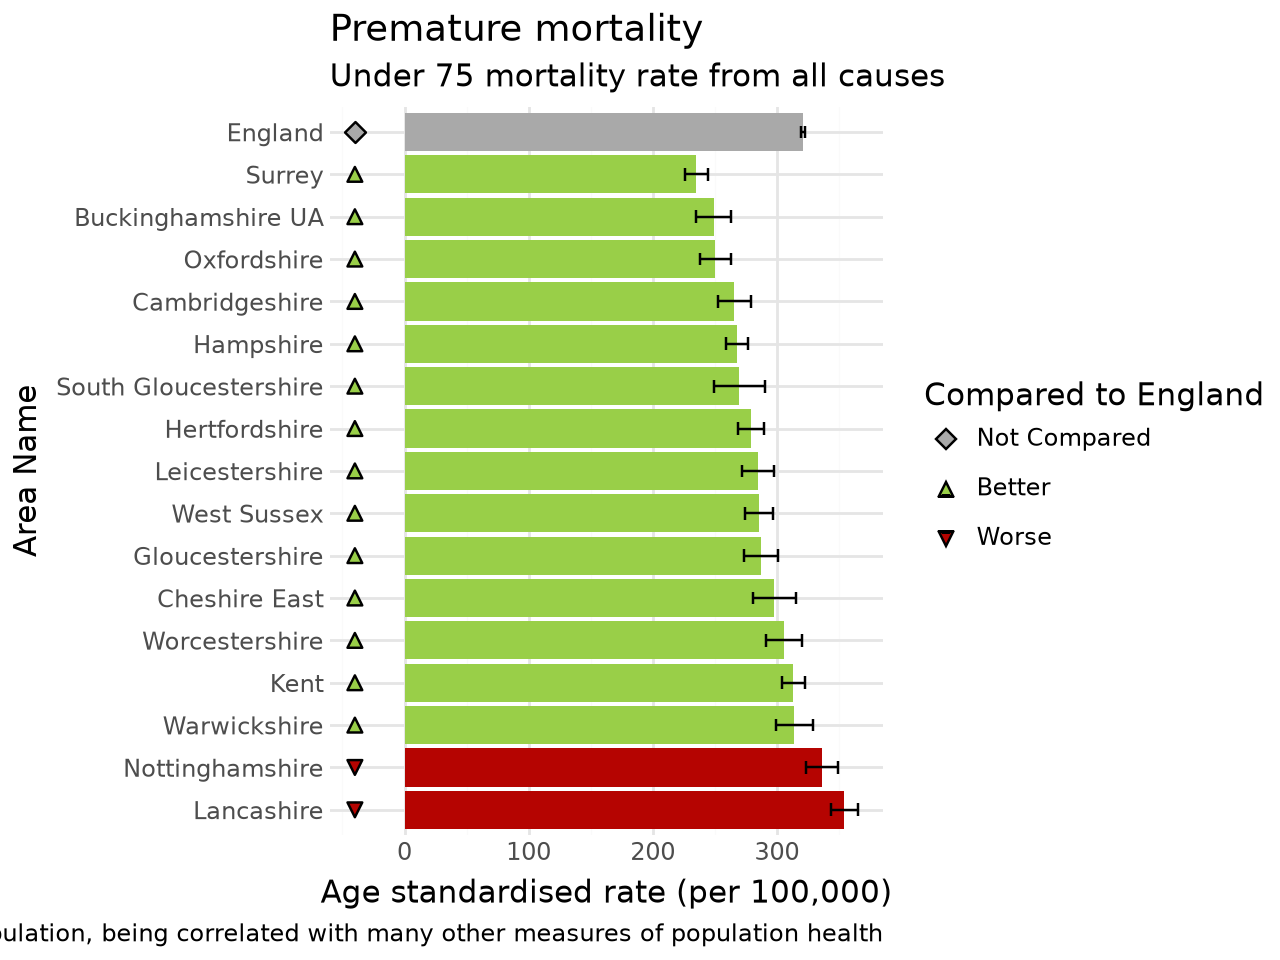

In [1]:
from phit_plot_helpers.plot import barplot
from phit_plot_helpers.fingertips import aget_data_for_indicators
import polars as pl

nn = {
    "E10000025": "Oxfordshire",
    "E10000015": "Hertfordshire",
    "E06000060": "Buckinghamshire",
    "E10000030": "Surrey",
    "E06000049": "Cheshire East",
    "E10000014": "Hampshire",
    "E06000025": "South Gloustershire",
    "E10000013": "Gloustershire",
    "E10000034": "Worcestershire",
    "E10000031": "Warwickshire",
    "E10000032": "West Sussex",
    "E10000016": "Kent",
    "E10000003": "Cambridgeshire",
    "E10000018": "Leicestershire",
    "E10000017": "Lancashire",
    "E10000024": "Nottinghamshire",
}
eng = "E92000001"

df = await aget_data_for_indicators(108)
df = df.filter(
    pl.col("Sex") == "Persons",
    pl.col("Time period") == "2025",
    pl.col("Category Type").is_null(),
    pl.col("Category").is_null()
)

nn_df = df.filter(
    pl.col("Area Code").is_in(nn.keys()),
)

comp_df = df.filter(
    pl.col("Area Code").is_in([eng]),
)

barplot(
    nn_df, 
    comp_df,
    "Premature mortality",
    "Under 75 mortality rate from all causes",
    "Premature mortality is a good high-level indicator of the overall health of a population, being correlated with many other measures of population health",
    lower_is_better=True
)

2026-07-15 13:28:33.906 | INFO     | phit_plot_helpers.fingertips:afrom_fingertips:45 - checking updates for indicator 108


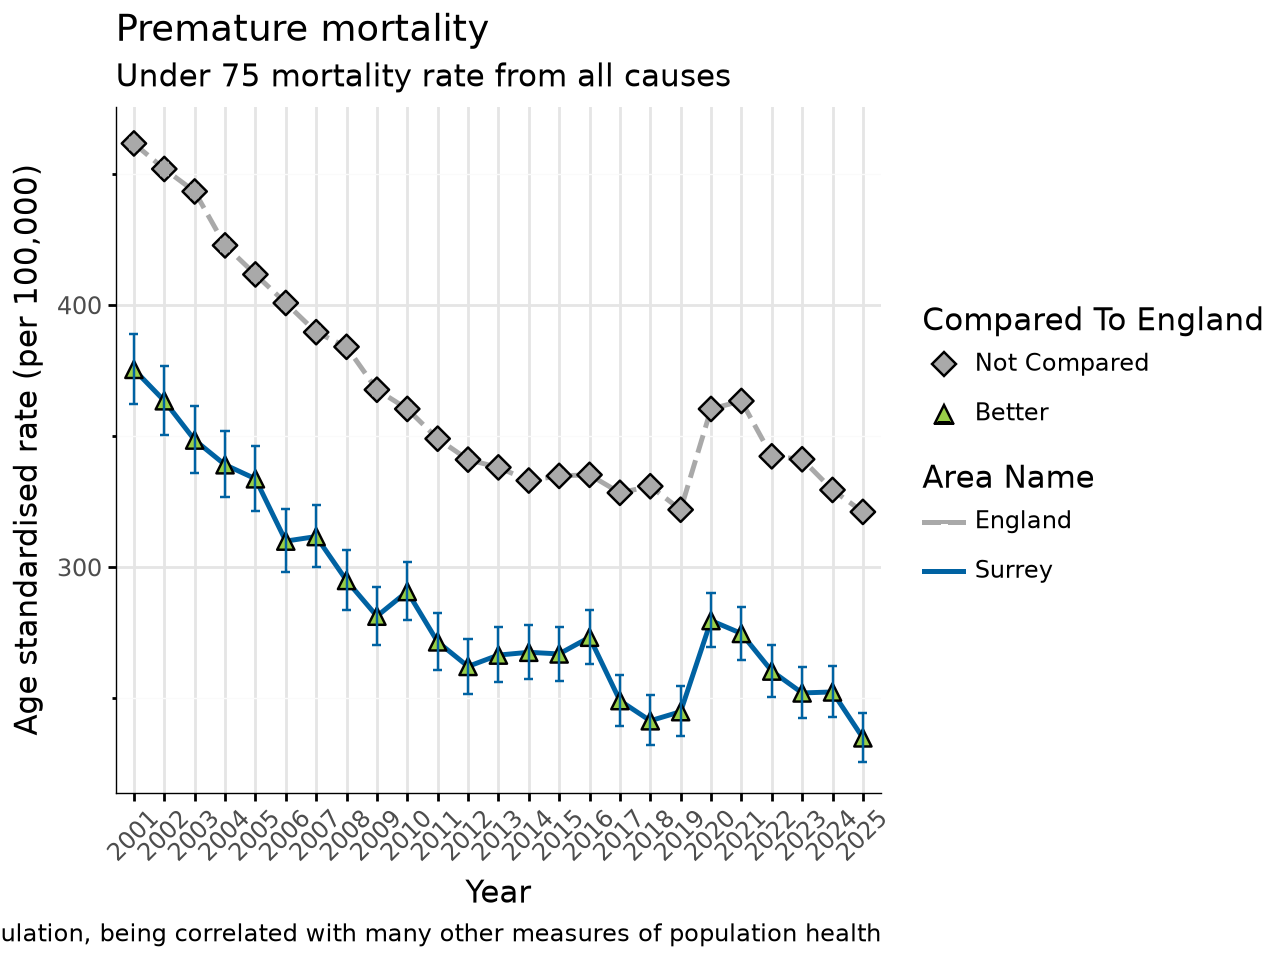

In [2]:
from phit_plot_helpers.plot import lineplot

df = await aget_data_for_indicators(108)
df = df.filter(
    pl.col("Sex") == "Persons",
    pl.col("Time period").str.len_chars() == 4,  # only get single years
    pl.col("Category Type").is_null(),
    pl.col("Category").is_null()
)

lineplot(
    df.to_pandas(),
    "Area Name",
    "Surrey",
    "England",
    "Premature mortality",
    "Under 75 mortality rate from all causes",
    "Premature mortality is a good high-level indicator of the overall health of a population, being correlated with many other measures of population health",
    lower_is_better=True
)